In [1]:
%cd /scratch/users/baranh/deep_0/SpherePackings
import os
import numpy as np
import torch
import time
import math
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm
import configparser
from diffuse_boost.spheres_in_cube import data_load_save
from datetime import datetime
from diffuse_boost.spheres_in_cube.plot_data_points import plot_3d
import diffuse_boost.spheres_in_Rd.data_evaluation as data_evaluation
from diffuse_boost.spheres_in_Rd.data_evaluation import plot_evaluations

from torchdiffeq import odeint
import schedulefree
from x_transformers import ContinuousTransformerWrapper, Encoder

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath, CondOTProbPath
from flow_matching.utils import ModelWrapper
from flow_matching.solver import ODESolver
from torch.distributions import Independent, Normal

from diffuse_boost import cfg

/scratch/users/baranh/deep_0/SpherePackings
file:  /scratch/users/baranh/deep_0/SpherePackings/diffuse_boost/__init__.py
here
Loaded configuration file /scratch/users/baranh/deep_0/SpherePackings/config.cfg!


In [2]:
# Continuous flow matching path with CondOT (linear) scheduler
FM_PATH = AffineProbPath(scheduler=CondOTScheduler())

# Model 

In [3]:
class FlowSetTransformer(nn.Module):
    class TimeEmbedFourier(nn.Module):
        def __init__(
            self,
            out_dim: int,
            fourier_dim: int,
            hidden: int,
            sigma: float = 1.0,
            include_poly: bool = True,
        ):
            super().__init__()
            fourier_dim = max(16, fourier_dim)
            # fixed (non-trainable) Fourier frequencies
            self.register_buffer("freqs", torch.randn(fourier_dim) * sigma, persistent=False)
            self.include_poly = include_poly
            in_dim = 2 * fourier_dim
            if include_poly:
                in_dim += 4  # [t, t^2, t^3, log(1+t)]
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.SiLU(),
                nn.Linear(hidden, out_dim),
            )

        def forward(self, t: torch.Tensor) -> torch.Tensor:
            # t: (B,) or (B,1) -> (B,)
            if t.ndim == 2:
                assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
                t = t[:, 0]
            t = t.contiguous()
            # Fourier features
            angles = (t[:, None] * self.freqs[None, :]) * (2.0 * math.pi)
            sin_feat = torch.sin(angles)
            cos_feat = torch.cos(angles)
            feats = [sin_feat, cos_feat]
            if self.include_poly:
                t1 = t
                t2 = t1 * t1
                t3 = t2 * t1
                tlog = torch.log1p(t1.clamp_min(0))
                feats += [t1[:, None], t2[:, None], t3[:, None], tlog[:, None]]

            h = torch.cat(feats, dim=-1)
            return self.net(h)

    def __init__(self, d: int = 3, **st_kwargs):
        super().__init__()
        self.d = d
        model_dim = int(st_kwargs.get("dim_hidden", 512))
        heads = int(st_kwargs.get("num_heads", 8))
        depth = int(st_kwargs.get("depth", 2))
        ff_mult = float(st_kwargs.get("ff_mult", 4.0))
        attn_do = float(st_kwargs.get("attn_dropout", 0.1))
        ff_do = float(st_kwargs.get("ff_dropout", 0.1))
        dim_time = int(st_kwargs.get("dim_time", max(64, 4 * d)))
        time_F = int(st_kwargs.get("time_fourier_dim", max(16, dim_time // 2)))
        time_hid = int(st_kwargs.get("time_hidden", 2 * dim_time))
        sigma = float(st_kwargs.get("time_fourier_sigma", 1.0))

        # conditioning setup
        cond_dim_in  = int(st_kwargs.get("cond_dim_in", 4))   # keep default 4: [r/L, N/scale_N, p_face, minsep/L]
        cond_hidden  = int(st_kwargs.get("cond_hidden", max(64, dim_time)))
        self.uses_cond = cond_dim_in > 0

        # Time embedding (B,) / (B,1) -> (B, dim_time)
        self.time_emb = self.TimeEmbedFourier(
            out_dim=dim_time, fourier_dim=time_F, hidden=time_hid,
            sigma=sigma, include_poly=True
        )

        if self.uses_cond:
            self.cond_mlp = nn.Sequential(
                nn.Linear(cond_dim_in, cond_hidden),
                nn.SiLU(),
                nn.Linear(cond_hidden, cond_hidden)
            )
            dim_cond = cond_hidden
        else:
            self.cond_mlp = None
            dim_cond = 0

        # per-point coords + time + (optional) cond
        self.token_in = nn.Linear(d + dim_time + dim_cond, model_dim)

        # FiLM generator takes [time ⊕ cond] jointly
        self.film_in_dim = dim_time + dim_cond
        self.timecond_to_film = nn.Sequential(
            nn.SiLU(),
            nn.Linear(self.film_in_dim, 2 * model_dim)
        )

        self.encoder = Encoder(
            dim = model_dim,
            depth=depth,
            heads=heads,
            layer_dropout=0.1,
            attn_dropout=attn_do,
            ff_dropout=ff_do,
            use_rmsnorm=True,
            ff_glu=True,
            ff_no_bias=True,
            attn_flash=True
        )

        self.token_out = nn.Linear(model_dim, d)
        # Zero-init output to start near 0 velocity (stabilizes FM training)
        nn.init.zeros_(self.token_out.weight)
        nn.init.zeros_(self.token_out.bias)

    def forward(
        self,
        t: torch.Tensor,
        x: torch.Tensor,
        cond: torch.Tensor = None,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        t    : (B,) or (B,1)
        x    : (B, d, Nmax)
        cond : (B, C) or None     with C=4 by default: [r/L, N/scale_N, p_face, minsep/L]
        mask : (B, Nmax) bool or 0/1; True = attend, False = ignore (padded)
        ->    (B, d, Nmax)
        """
        B, d, N = x.shape
        assert d == self.d, f"Expected d={self.d}, got {d}"
        device = x.device
        dtype = x.dtype

        # --- time ---
        t = t.to(device=device, dtype=dtype)
        if t.ndim == 2:
            assert t.shape[1] == 1, f"t must be (B,) or (B,1); got {t.shape}"
            t_1d = t[:, 0]
        else:
            t_1d = t
        t_embed = self.time_emb(t_1d)  # (B, dim_time)

        # --- cond (classifier-free guidance: None -> zeros) ---
        if self.uses_cond:
            if cond is None:
                cond = torch.zeros(B, self.cond_mlp[0].in_features, device=device, dtype=dtype)
            else:
                cond = cond.to(device=device, dtype=dtype)
            c_embed = self.cond_mlp(cond)        # (B, dim_cond)
        else:
            c_embed = None

        # --- tokens (points) ---
        tokens = x.permute(0, 2, 1).contiguous()            # (B, N, d)
        if c_embed is not None:
            tc = torch.cat([t_embed, c_embed], dim=-1)      # (B, dim_time+dim_cond)
            tc_rep = tc[:, None, :].expand(B, N, -1)        # (B, N, ...)
            h = torch.cat([tokens, tc_rep], dim=-1)         # (B, N, d + dim_time + dim_cond)
            film_in = tc                                     # (B, dim_time+dim_cond)
        else:
            t_rep = t_embed[:, None, :].expand(B, N, -1)    # (B, N, dim_time)
            h = torch.cat([tokens, t_rep], dim=-1)          # (B, N, d + dim_time)
            film_in = t_embed                                # (B, dim_time)

        h = self.token_in(h)                                 # (B, N, model_dim)

        # --- FiLM modulation from joint [time ⊕ cond] ---
        gamma_beta = self.timecond_to_film(film_in)          # (B, 2*model_dim)
        gamma, beta = gamma_beta.chunk(2, dim=-1)            # each (B, model_dim)
        gamma = gamma[:, None, :]
        beta  = beta[:, None, :]
        h = h * (1 + gamma) + beta

        # --- mask handling ---
        if mask is not None:
            # ensure boolean on correct device
            mask = mask.to(device=device)
            if mask.dtype != torch.bool:
                mask = mask != 0
            # (B, N, 1) multiplicative mask helps stabilize pre-encoder stats
            h = h * mask[:, :, None].to(h.dtype)

        # --- encoder (expects mask with True=attend) ---
        h = self.encoder(h, mask=mask)                       # (B, N, model_dim)

        out = self.token_out(h).permute(0, 2, 1).contiguous()  # (B, d, N)

        # Zero out padded tokens in the output as well (nice-to-have, harmless if loss already masks)
        if mask is not None:
            out = out * mask[:, None, :].to(out.dtype)

        return out

In [4]:
#FlowSetTransformer()

# Training

In [5]:
_TRI_CACHE = {}
def distance_penalty(output, radius, margin=0.0, beta=10.0, p=2, q=0.2, eps=1e-12, mask: torch.Tensor = None):
    """
    output : (B,d,N)
    radius : float or (B,) per-sample radius
    margin : float or (B,) per-sample margin
    mask   : optional (B,N), True=attend
    """
    B, d, N = output.shape
    coords = output.permute(0, 2, 1).contiguous()             # (B,N,d)
    dmat = torch.cdist(coords, coords) + eps                  # (B,N,N)

    r = torch.as_tensor(radius, device=output.device, dtype=output.dtype)
    m = torch.as_tensor(margin, device=output.device, dtype=output.dtype)
    if r.ndim == 1: r = r.view(B, 1, 1)
    else:           r = r.reshape(B, 1, 1)
    if m.ndim == 1: m = m.view(B, 1, 1)
    else:           m = m.reshape(B, 1, 1)

    gap = (2 * r + m) - dmat                                  # (B,N,N)
    v = F.softplus(beta * gap) / beta                         # (B,N,N)

    # mask out padded tokens
    if mask is not None:
        pairmask = (mask[:, :, None] & mask[:, None, :]).to(v.dtype)  # (B,N,N)
        v = v * pairmask

    key = (output.device, N)
    tri = _TRI_CACHE.get(key)
    if tri is None:
        tri = torch.triu_indices(N, N, offset=1, device=output.device)
        _TRI_CACHE[key] = tri
    v = v[:, tri[0], tri[1]]                                   # (B, pairs)

    if p != 1:
        v = v.pow(p)

    Pairs = max(1, v.size(1))
    k = max(1, int(q * Pairs))
    topk, _ = torch.topk(v, k=k, dim=1, largest=True, sorted=False)
    return topk.mean()


def _box_clamp(x, r, L):
    """
    Clamp per-sample: r can be scalar or (B,) or (B,1,1).
    x: (B,d,N)
    """
    r = torch.as_tensor(r, device=x.device, dtype=x.dtype)
    L = torch.as_tensor(L, device=x.device, dtype=x.dtype)
    if r.ndim == 0:
        lo = r
        hi = L - r
    else:
        lo = r.view(-1, 1, 1)
        hi = L.view(-1, 1, 1) - lo
    return x.clamp(lo, hi)

def sample_t(B, device, small_t_weight=0.5, gamma=2.0):
    s = torch.rand(B, device=device)
    t_small = s**gamma
    use_small = (torch.rand(B, device=device) < small_t_weight).float()
    return use_small * t_small + (1 - use_small) * s

def save_with_plot(model, optimizer, history, epoch, params, sec):
    save_dir = sec
    os.makedirs(save_dir, exist_ok=True)
    loss = history[-1,2]
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    name = f"flow_model_loss={loss:.4f}_{ts}.pth"
    path = os.path.join(save_dir, name)
    data_load_save.save_model(path, model, optimizer, epoch, params)

    plt.figure(figsize=(12,6))
    plt.plot(history[:,0], label="Flow MSE Loss")
    plt.plot(history[:,1], label="Distance Penalty")
    plt.plot(history[:,2], label="Total Loss")
    plt.yscale('log')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.grid()
    plt.savefig(os.path.join(save_dir, f"flow_loss_{ts}.png"))


def _sample_x1_box_faces_per_batch(
    x0, r, L, p_face_batch=None, jitter=5e-3,
    inward_eps=1e-4, stratified=False, exact_count=False
):
    """
    x0: (B,d,N) (only for shape/device)
    r : float or (B,) per-sample radius
    """
    B, d, N = x0.shape
    device, dtype = x0.device, x0.dtype
    r = torch.as_tensor(r, device=device, dtype=dtype)            # () or (B,)
    L = torch.as_tensor(L, device=device, dtype=dtype)

    # base interior samples
    if not stratified:
        u = torch.rand(B, d, N, device=device, dtype=dtype) * (L - 2*r.view(-1,1,1) if r.ndim>0 else (L-2*r)) + (r.view(-1,1,1) if r.ndim>0 else r)
    else:
        u = torch.empty(B, d, N, device=device, dtype=dtype)
        for ax in range(d):
            bins = (torch.arange(N, device=device, dtype=dtype)[None, None, :]
                    + torch.rand(B, 1, N, device=device, dtype=dtype)) / N
            vals = (r.view(-1,1,1) if r.ndim>0 else r) + (L - 2*(r.view(-1,1,1) if r.ndim>0 else r)) * bins
            perm = torch.argsort(torch.rand(B, 1, N, device=device), dim=-1)
            u[:, ax:ax+1, :] = vals.gather(2, perm)

    noise = jitter * torch.randn_like(u)

    if p_face_batch is not None:
        p = p_face_batch.to(device=device, dtype=dtype).clamp(0, 1)  # (B,)
        if exact_count:
            K = torch.distributions.Binomial(total_count=N, probs=p).sample().to(torch.long)
            keys = torch.rand(B, N, device=device)
            order = torch.argsort(keys, dim=1)
            mask = torch.zeros(B, N, device=device, dtype=torch.bool)
            for b in range(B):
                k = int(K[b].item())
                if k > 0:
                    mask[b, order[b, :k]] = True
        else:
            mask = (torch.rand(B, N, device=device) < p[:, None])   # (B,N)

        axis = torch.randint(0, d, (B, N), device=device)
        side = torch.randint(0, 2, (B, N), device=device)

        low_vals  = (r[:, None] + inward_eps) if r.ndim > 0 else (r + inward_eps)
        high_vals = (L - (r[:, None] + inward_eps)) if r.ndim > 0 else (L - (r + inward_eps))
        low_vals  = low_vals.expand(B, N)
        high_vals = high_vals.expand(B, N)
        face_pos  = torch.where(side == 0, low_vals, high_vals)     # (B,N)
        axis_oh = torch.zeros(B, d, N, device=device, dtype=dtype)
        axis_oh.scatter_(1, axis.unsqueeze(1), 1.0)
        noise = noise * (1.0 - axis_oh * mask[:, None, :].to(dtype))

        # add jitter & clamp
        u = _box_clamp(u + noise, r, L)

        # overwrite the axis coord at face tokens
        ar = torch.arange(B, device=device)[:, None].expand(B, N)
        nr = torch.arange(N, device=device)[None, :].expand(B, N)
        u[ar, axis, nr] = torch.where(mask, face_pos, u[ar, axis, nr])
    else:
        u = _box_clamp(u + noise, r, L)

    return u

def train_flow_model(
    model, optimizer, loader, num_epochs,
    sphere_radius, mse_strength, dist_strength,
    clip_min, clip_max, device, params, save_path
):
    model.train().to(device)
    optimizer.train()
    history, best = [], 1e9

    L = float(clip_max)  # box size upper bound, lower bound ~0
    for epoch in tqdm(range(num_epochs), desc="Training", dynamic_ncols=True):
        ep_losses=[]
        ratio = 0.5 * (1 - np.cos(np.pi * min(1.0, epoch / (0.5 * num_epochs))))
        for x_0, cond, mask in loader:
            x_0   = x_0.to(device)
            cond  = cond.to(device)
            mask  = mask.to(device)                             # (B,Nmax) bool
            B, d, N = x_0.shape

            # per-sample radius from cond: cond[:,0] = r/L
            r_batch = (cond[:, 0] * L).to(x_0.dtype)            # (B,)
            cond_in = cond  # None if torch.rand(()) < 0.1 else cond

            # source x_1 uses per-sample p_face
            p_face_batch = cond[:, 2].clamp(0, 1)               # (B,)
            x_1 = _sample_x1_box_faces_per_batch(x_0, r_batch, L=L,
                                                 p_face_batch=p_face_batch, jitter=5e-3)
            t_in = sample_t(B, device=device, small_t_weight=0.5, gamma=2.0)  # (B,)

            # path sample (same as your code)
            path_sample = FM_PATH.sample(t=t_in, x_0=x_0, x_1=x_1)
            x_t  = path_sample.x_t
            dx_t = path_sample.dx_t

            # model prediction (pass mask)
            u_pred = model(t_in, _box_clamp(x_t, r_batch, L), cond=cond_in, mask=mask)

            # Flow-matching loss with mask
            # (B,d,N) -> elementwise MSE, then mask tokens
            se = F.mse_loss(u_pred, dx_t, reduction='none')     # (B,d,N)
            se = se * mask[:, None, :].to(se.dtype)
            denom = mask.sum().clamp_min(1)
            loss_fm = se.sum() / denom

            # penalty (projected x0 from u_pred) — unchanged math, per-sample r & mask
            eps_t = 1e-3
            with torch.no_grad():
                sch0 = FM_PATH.scheduler(t_in)
                sch1 = FM_PATH.scheduler((t_in + eps_t).clamp_max(1.0))
            alpha_dot = ((sch1.alpha_t - sch0.alpha_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            sigma_dot = ((sch1.sigma_t - sch0.sigma_t) / eps_t).view(-1, 1, 1).to(x_t.dtype)
            alpha_dot_safe = alpha_dot.sign() * alpha_dot.abs().clamp_min(1e-6)
            x0_proj = (u_pred - sigma_dot * x_1) / alpha_dot_safe

            pen = distance_penalty(
                x0_proj, r_batch,
                margin=0.02 * r_batch,
                beta=80.0,
                p=2,
                q=0.20,
                mask=mask
            )

            loss = mse_strength * loss_fm + dist_strength * ratio * pen

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ep_losses.append([loss_fm.item(), pen.item(), loss.item()])

        avg = np.mean(ep_losses, axis=0)
        history.append(avg)
        print(f"Epoch {epoch+1}/{num_epochs} | FM={avg[0]:.4f} Pen={avg[1]:.4f} Tot={avg[2]:.4f}")

    save_with_plot(model, optimizer, np.array(history), num_epochs-1, params, save_path)
    return model, np.array(history)


@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, 
                      cond_loader=None, return_masks = False):

    # Hyperparameters
    N_steps = 100
    ode_method = 'midpoint'
    ode_step_cap = 0.1
    jitter = 5e-3
    eps_nrm = 1e-6
    proj_outer_iters = 8
    alpha_proj = 0.25
    contact_q = 1.0
    wall_weight = 1.0
    wall_margin = 0.05
    prox_iters = 10
    prox_step = 0.2
    prox_lambda = 2.0
    final_passes = 20
    tol_finish = 1e-8

    L = torch.tensor(float(clip_max), device=device)
    r_default = torch.tensor(float(sphere_radius), device=device)

    def _clamp_box_local(x, r_b):
        return _box_clamp(x, r_b, L)

    class _FMVF:
        def __init__(self, mdl, cond, mask):
            self.mdl, self.cond, self.mask = mdl, cond, mask
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond, mask=self.mask) if self.cond is not None else self.mdl(tb, x, mask=self.mask)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond, mask, r_b):
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)
        solver = ODESolver(velocity_model=_FMVF(model, cond, mask))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box_local(x_end, r_b)

    def _active_overlap(u, r_b, mask, for_stop=False):
        """
        Returns overlap>=0 on active pairs only; masked pairs set to 0.
        """
        B, d, N = u.shape
        P = u.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r_b.view(-1, 1, 1)) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)

        overlap = (2.0 * r_b.view(-1,1,1) - dist)   # (B,N,N)
        eye = torch.eye(N, device=u.device, dtype=torch.bool)[None]
        pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
        overlap = torch.where(pairmask, overlap, torch.zeros_like(overlap))
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, r_b, mask, margin_frac=0.05, scale=1.0):
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r_b).view(-1, 1, 1)
        for ax in range(d):
            dl = u[:, ax, :] - r_b.view(-1, 1)                  # dist to low face
            dh = (L - r_b).view(-1, 1) - u[:, ax, :]            # dist to high face
            near_low  = (dl < thr.view(-1,1))
            near_high = (dh < thr.view(-1,1))
            delta[:, ax, :] += torch.where(near_low,  (thr.view(-1,1) - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr.view(-1,1) - dh), 0.0)
        # zero out on padded tokens
        delta = delta * mask[:, None, :].to(delta.dtype)
        return scale * delta

    def _project_terminal(u, r_b, mask):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, r_b, mask, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, r_b, mask, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box_local(u + alpha_proj * (delta_pairs + delta_walls), r_b)
        return u

    def _Jt_h_at_state(u_next, r_b, mask):
        overlap, n, eye = _active_overlap(u_next, r_b, mask, for_stop=False)
        active = (overlap > 0) & (~eye)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        jt_walls = _wall_push(u_next, r_b, mask, margin_frac=wall_margin, scale=1.0)
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask):
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
            u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
            jt_h = _Jt_h_at_state(u_next, r_b, mask)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box_local(u - prox_step * grad, r_b)
        return u

    def _final_polish(u, r_b, mask):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                break
            u = _project_terminal(u, r_b, mask)
        return u

    model.eval()
    optimizer.eval()

    samples, masks_out, remaining = [], [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    while remaining > 0:
        bs = min(batch_size, remaining)
        if cond_iter is not None:
            try:
                x_dummy, cond, mask = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond, mask = next(cond_iter)
            cond = cond.to(device)
            mask = mask.to(device)                  # (B, Ncond_max)
            if cond.size(0) > bs:
                cond = cond[:bs]
                mask = mask[:bs]
            #extrapolative de novo design
            cond = cond.clone()
            cond[:, 3] = cond[:, 3] + 0.05

            # per-sample radius
            r_batch = (cond[:, 0] * L).to(torch.float32)        # (B,)

            # we keep fixed output width N=num_points; adapt mask to that width
            if mask.size(1) < num_points:
                pad = torch.zeros(mask.size(0), num_points - mask.size(1), dtype=mask.dtype, device=device)
                mask = torch.cat([mask, pad], dim=1)
            elif mask.size(1) > num_points:
                mask = mask[:, :num_points]
        else:
            cond = None
            r_batch = r_default.repeat(bs)                      # (B,)
            mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)

        # Initialize u0 at tau=0, clamp
        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r_batch, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        u0 = _clamp_box_local(u0, r_batch)
        u = u0.clone()

        # tau grid evolution
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps
            # forward shoot to tau=1
            u1 = _ode_solve_with_model(u, tau, 1.0, cond, mask, r_batch)
            # terminal projection
            u_proj = _project_terminal(u1, r_batch, mask)
            # relaxed reverse step
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond, r_batch, mask)

        u = _final_polish(u, r_batch, mask)
        samples.append(u.cpu().numpy())
        if return_masks:
            masks_out.append(mask.cpu().numpy())
        remaining -= bs

    samples_np = np.concatenate(samples, axis=0)          # (num_samples, d, num_points)
    if return_masks:
        masks_np = np.concatenate(masks_out, axis=0)      # (num_samples, num_points)
        return samples_np, masks_np
    return samples_np


In [6]:
from bisect import bisect_right
import torch
from torch.utils.data import Dataset, DataLoader, Subset

#Collate: pad to max N and build mask
def variable_length_collate(batch):
    """
    batch: list of (x:(d,N_i), cond:(4,), mask:(N_i,))
    -> x_pad:(B,d,N_max), cond:(B,4), mask:(B,N_max)
    """
    d = batch[0][0].shape[0]
    Ns = [item[0].shape[-1] for item in batch]
    Nmax = max(Ns)
    B = len(batch)
    dtype = batch[0][0].dtype
    device = batch[0][0].device

    x = torch.zeros(B, d, Nmax, dtype=dtype, device=device)
    mask = torch.zeros(B, Nmax, dtype=torch.bool, device=device)
    cond = torch.stack([item[1] for item in batch], dim=0)

    for b, (xb, _, mb) in enumerate(batch):
        n = xb.shape[-1]
        x[b, :, :n] = xb
        mask[b, :n] = True

    return x, cond, mask



class SpherePackingDataset(Dataset):
    def __init__(self,
                 path,
                 radius,
                 box_len,
                 tol=1e-4,
                 chunk=2048,
                 scale_N=128,
                 max_samples=None,
                 mixed_cond_path=None):

        self.L = float(box_len)
        self.tol = float(tol)
        self.scale_N = int(scale_N)
        self.chunk = int(chunk)

        with torch.inference_mode():
            raw = torch.load(path, map_location="cpu")

            if mixed_cond_path is not None:
                assert isinstance(raw, (list, tuple)) and len(raw) > 0, \
                    "With mixed_cond_path set, dataset_path must load a non-empty list of (Mi,d,Ni) tensors."
                self.groups = []
                total_M = 0
                for gi, t in enumerate(raw):
                    if t.dtype not in (torch.float32, torch.float64):
                        t = t.float()
                    if t.max().item() > 1.0:
                        print(f"[Group {gi}] Normalizing box size")
                        t = t / 8.78968670811599928
                    assert t.ndim == 3, f"group {gi}: expected (M,d,N), got {tuple(t.shape)}"
                    Mi, d, Ni = t.shape
                    if gi == 0:
                        self.d = int(d)
                    else:
                        assert int(d) == self.d, f"group {gi}: dimension mismatch: got d={int(d)} expected d={self.d}"
                    self.groups.append({"data": t.contiguous(), "M": Mi, "N": Ni})
                    total_M += Mi

                # Load (N, r) conditions; accept either (Total,2) or (G,2,M)
                cond_raw = torch.load(mixed_cond_path, map_location="cpu")
                is_flat = (cond_raw.ndim == 2 and cond_raw.shape[1] == 2)
                is_grouped = (cond_raw.ndim == 3 and cond_raw.shape[1] == 2 and cond_raw.shape[0] == len(self.groups))

                if not (is_flat or is_grouped):
                    raise ValueError(
                        f"mixed_sphere_cond.pt must have shape (TotalSamples, 2) or (num_groups, 2, M_group). "
                        f"Got {tuple(cond_raw.shape)}"
                    )

                use_total = total_M if (max_samples is None) else min(int(max_samples), total_M)
                starts = [0]
                for g in self.groups:
                    starts.append(starts[-1] + g["M"])
                self.starts = starts
                self.total_M = use_total

                dtype0 = self.groups[0]["data"].dtype

                conds_list = []
                done = 0
                for gi, g in enumerate(self.groups):
                    if done >= use_total:
                        break
                    data_g = g["data"]                      # (M_i, d, N_i)
                    Mi, d, Ni = data_g.shape
                    take = min(Mi, use_total - done)
                    data_g = data_g[:take]

                    if is_flat:
                        # cond_raw: (Total, 2) -> slice for this group
                        s = self.starts[gi]
                        r_vec = cond_raw[s:s+take, 1].to(dtype0)     # (take,)
                        Ns_slice = cond_raw[s:s+take, 0].to(torch.long)
                    else:
                        # cond_raw: (G, 2, M)
                        assert cond_raw.shape[2] >= Mi, \
                            f"group {gi}: cond has M={cond_raw.shape[2]} but data has M={Mi}"
                        r_vec = cond_raw[gi, 1, :take].to(dtype0)     # (take,)
                        Ns_slice = cond_raw[gi, 0, :take].to(torch.long)

                    mism = int((Ns_slice != Ni).sum().item())
                    if mism > 0:
                        print(f"Warning: N mismatch in group {gi}: expected {Ni}, "
                              f"found {mism}/{take} different values in mixed_sphere_cond.pt")

                    # p_face (per-sample proportion of tokens on any face)
                    L = self.L
                    # broadcast r per-sample across (d,N)
                    near_r  = (data_g - r_vec[:, None, None]).abs() <= self.tol
                    near_lr = (data_g - (L - r_vec)[:, None, None]).abs() <= self.tol
                    on_face_any = (near_r | near_lr).any(dim=1)            # (take,N_i)
                    p_face = on_face_any.float().mean(dim=1)               # (take,)

                    #minsep per sample (Gram trick)
                    minsep = torch.empty(take, dtype=dtype0)
                    if Ni < 2:
                        minsep.fill_(float("inf"))
                    else:
                        for s in range(0, take, self.chunk):
                            e = min(take, s + self.chunk)
                            xb = data_g[s:e]                          # (B,d,N)
                            P = xb.permute(0, 2, 1).contiguous()      # (B,N,d)
                            G = P @ P.transpose(1, 2)                 # (B,N,N)
                            sq = (P * P).sum(dim=2)                   # (B,N)
                            dist2 = sq[:, :, None] + sq[:, None, :] - 2.0 * G
                            dist2.clamp_(min=0.0)
                            Bn, Nn = dist2.shape[:2]
                            eye = torch.eye(Nn, dtype=torch.bool).expand(Bn, -1, -1)
                            dist2.masked_fill_(eye, float("inf"))
                            minsep[s:e] = dist2.amin(dim=-1).amin(dim=-1).sqrt_()

                    # cond components: [r/L, N/scale_N, p_face, minsep/L]
                    r_over_L = (r_vec / L).to(dtype0)
                    N_scaled = torch.full((take,), float(Ni) / float(self.scale_N), dtype=dtype0)
                    minsep_L = (minsep / L).to(dtype0)
                    cond_g = torch.stack([r_over_L, N_scaled, p_face.to(dtype0), minsep_L], dim=1)  # (take,4)
                    conds_list.append(cond_g)
                    done += take

                self.cond = torch.cat(conds_list, dim=0).contiguous()  # (use_total,4)
                self.mixed_mode = True
                self.radius = None
                self.d = int(self.groups[0]["data"].shape[1])

                print(f"Loaded (mixed) {path}: {len(self.groups)} groups, total {self.total_M} samples "
                      f"| precomputed conds: {tuple(self.cond.shape)}")

            # fixed N, fixed r MODE
            else:
                data = raw
                if data.dtype not in (torch.float32, torch.float64):
                    data = data.float()
                if data.max().item() > 1.0:
                    print("Normalizing Box size")
                    data = data / 8.78968670811599928
                assert data.ndim == 3, f"expected (M,d,N), got {tuple(data.shape)}"
                if max_samples is not None:
                    if not isinstance(max_samples, int) or max_samples <= 0:
                        raise ValueError("max_samples must be a positive integer")
                    data = data[:max_samples]

                data = data.contiguous()
                M, d, N = data.shape
                self.data = data
                self.M, self.d, self.N = M, d, N
                self.radius = float(radius)
                dtype = self.data.dtype

                # try load cond cache (legacy)
                cond_cache = f"{path}.cond.pt"
                cond_loaded = False
                if os.path.exists(cond_cache):
                    try:
                        pack = torch.load(cond_cache, map_location="cpu")
                        if isinstance(pack, dict) and "cond" in pack:
                            cond = pack["cond"]
                            meta = pack.get("meta", {})
                        else:
                            cond, meta = pack, {}
                        if cond.shape == (M, 4) and abs(meta.get("r", self.radius) - self.radius) < 1e-12 \
                           and abs(meta.get("L", self.L) - self.L) < 1e-12 \
                           and meta.get("M", M) == M and meta.get("N", N) == N \
                           and abs(meta.get("tol", self.tol) - self.tol) < 1e-12 and meta.get("scale_N", self.scale_N) == self.scale_N:
                            self.cond = cond.to(dtype=dtype, copy=False).contiguous()
                            cond_loaded = True
                            print(f"Loaded cond cache: {cond_cache}")
                    except Exception:
                        cond_loaded = False

                if not cond_loaded:
                    # p_face per sample (legacy, fixed r)
                    near_r  = (self.data - self.radius).abs() <= self.tol
                    near_lr = (self.data - (self.L - self.radius)).abs() <= self.tol
                    on_face_any = (near_r | near_lr).any(dim=1)            # (M,N)
                    p_face = on_face_any.float().mean(dim=1)               # (M,)

                    # min-sep per sample
                    minsep = torch.empty(M, dtype=dtype)
                    if N < 2:
                        minsep.fill_(float("inf"))
                    else:
                        for s in range(0, M, self.chunk):
                            e = min(M, s + self.chunk)
                            xb = self.data[s:e]                        # (B,d,N)
                            P = xb.permute(0, 2, 1).contiguous()       # (B,N,d)
                            G = P @ P.transpose(1, 2)                  # (B,N,N)
                            sq = (P * P).sum(dim=2)                    # (B,N)
                            dist2 = sq[:, :, None] + sq[:, None, :] - 2.0 * G
                            dist2.clamp_(min=0.0)
                            Bn, Nn = dist2.shape[:2]
                            eye = torch.eye(Nn, dtype=torch.bool).expand(Bn, -1, -1)
                            dist2.masked_fill_(eye, float("inf"))
                            minsep[s:e] = dist2.amin(dim=-1).amin(dim=-1).sqrt_()

                    # cond vector [r/L, N/scale_N, p_face, minsep/L]
                    r_over_L = torch.full((M,), self.radius / self.L, dtype=dtype)
                    N_scaled = torch.full((M,), float(self.N) / float(self.scale_N), dtype=dtype)
                    minsep_L = (minsep / self.L).to(dtype)
                    self.cond = torch.stack([r_over_L, N_scaled, p_face.to(dtype), minsep_L], dim=1).contiguous()

                    # save tiny cache
                    meta = {"r": self.radius, "L": self.L, "M": M, "N": N, "tol": self.tol, "scale_N": self.scale_N}
                    try:
                        torch.save({"cond": self.cond, "meta": meta}, cond_cache)
                        print(f"Saved cond cache: {cond_cache}")
                    except Exception as e:
                        print(f"Warning: failed to save cond cache ({e})")

                # For uniformity with mixed mode
                self.mixed_mode = False
                self.total_M = self.M
                self.starts = [0, self.M]
                print(f"Loaded {path}, shape {tuple(self.data.shape)} | precomputed conds: {tuple(self.cond.shape)}")

    def __len__(self):
        return self.total_M

    def __getitem__(self, idx):
        """
        Returns:
          x    : (d, N_i)
          cond : (4,)   -> [r/L, N/scale_N, p_face, minsep/L]
          mask : (N_i,) -> True for valid tokens (attend), False for padded (none here; padding happens in collate)
        """
        if self.mixed_mode:
            # locate group
            gi = bisect_right(self.starts, idx) - 1
            k = idx - self.starts[gi]
            g = self.groups[gi]
            x = g["data"][k]            # (d, N_i)
            N_i = x.shape[-1]
            mask = torch.ones(N_i, dtype=torch.bool)
            cond = self.cond[idx]       # (4,)
            return x, cond, mask
        else:
            x = self.data[idx]          # (d, N)
            N = x.shape[-1]
            mask = torch.ones(N, dtype=torch.bool)
            cond = self.cond[idx]
            return x, cond, mask

# Run

Loaded (mixed) diffuse_boost/output/new_sim/mixed_sphere.pt: 40 groups, total 408000 samples | precomputed conds: (408000, 4)
Train size: 405960 | Test size: 2040


Training:   2%|█▋                                                                                 | 1/50 [01:01<50:02, 61.28s/it]

Epoch 1/50 | FM=0.3149 Pen=0.0009 Tot=0.3149


Training:   4%|███▎                                                                               | 2/50 [02:02<48:56, 61.17s/it]

Epoch 2/50 | FM=0.2768 Pen=0.0006 Tot=0.2768


...

Training:  98%|████████████████████████████████████████████████████████████████████████████████▎ | 49/50 [49:36<01:00, 60.64s/it]

Epoch 49/50 | FM=0.2183 Pen=0.0004 Tot=0.2191


Training: 100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [50:37<00:00, 60.74s/it]

Epoch 50/50 | FM=0.2191 Pen=0.0004 Tot=0.2200
##### Save model to diffuse_boost/output/saved_models/flow_model_loss=0.2200_20250907_121128.pth at epoch=49 created with model parameters: {'dim_hidden': 512, 'num_heads': 8, 'cond_dim_in': 4, 'dim_out': 3}\#####
Saved with additional metadata: {'type': 'model'}


Saved 100 samples as (B, d, N=89) to diffuse_boost/output/generated_sets/flow_gen_20250907_121142.pt


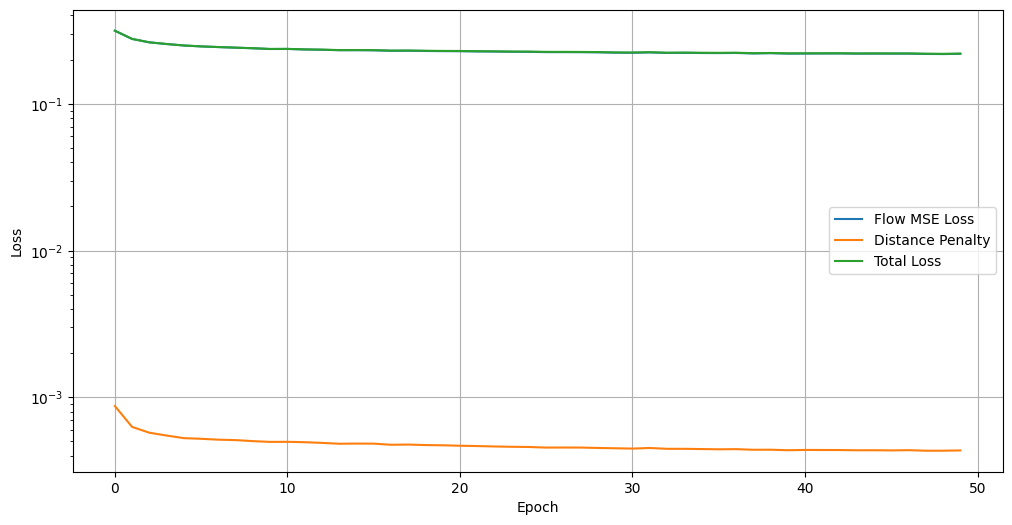

In [7]:
sec = cfg['flow_matching']
d = int(sec['dimension'])
bs = int(sec['batch_size'])
path = sec['dataset_path']
lr = float(sec['learning_rate'])
epochs = int(sec['num_epochs'])
radius = float(sec['sphere_radius'])   # kept for backward compat; ignored if mixed_cond_path is set
mse_s  = float(sec['mse_strength'])
pen_s  = float(sec['distance_penality_strength'])
clip_r = float(sec['clip_sample_range'])
save_m = sec['save_model_path']
num_new= int(sec.get('sample_new_points', 2500))
batch_n= int(sec.get('sample_new_points_batch_size', 100))
pts = int(sec['num_spheres'])
save_g = sec['save_generated_path']
mixed_cond_path = sec.get('mixed_cond_path', None)  # e.g. "mixed_sphere_cond.pt"

dev = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
full_ds = SpherePackingDataset(
    path,
    radius=radius,
    box_len=clip_r,
    tol=1e-4,
    chunk=2048,
    scale_N=128,
    max_samples=None,
    mixed_cond_path=mixed_cond_path
)

split_seed = int(sec.get('split_seed', 1234))
test_fraction= float(sec.get('test_fraction', 0.005))
gen = torch.Generator().manual_seed(split_seed)
perm = torch.randperm(len(full_ds), generator=gen)
test_size = max(1, int(round(len(full_ds) * test_fraction)))
test_idx = perm[:test_size].tolist()
train_idx = perm[test_size:].tolist()
train_ds = Subset(full_ds, train_idx)
test_ds = Subset(full_ds, test_idx)

train_loader = DataLoader(train_ds, batch_size=bs, num_workers=4, shuffle=True,
                          collate_fn=variable_length_collate, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_n, num_workers=4, shuffle=False,
                          collate_fn=variable_length_collate, pin_memory=True)

print(f"Train size: {len(train_ds)} | Test size: {len(test_ds)}")


st_kwargs = {
    'dim_hidden': int(sec.get('dim_hidden', 512)),
    'num_heads':  int(sec.get('num_heads', 8)),
    'cond_dim_in': 4,
    'dim_out': d
}


# Ensure the model expects the 4-dim cond vector we feed from the dataloader
st_kwargs = dict(st_kwargs)
st_kwargs.setdefault("cond_dim_in", 4)  # [r/L, N/scale_N, p_face, minsep/L]

model = FlowSetTransformer(d, **st_kwargs).to(dev)
opt = schedulefree.RAdamScheduleFree(model.parameters(), lr=lr)

model, hist = train_flow_model(
    model, opt, train_loader, epochs,
    radius, mse_s, pen_s,
    clip_r, clip_r, dev,
    st_kwargs, save_m
)


gen_points = pts
base_ds = getattr(train_loader.dataset, 'dataset', None)
if base_ds is not None and getattr(base_ds, 'mixed_mode', False):
    maxN = max(g["N"] for g in base_ds.groups)
    if gen_points is None or gen_points <= 0:
        gen_points = maxN

samples, masks = sample_flow_model(
    model, opt, num_new, batch_n, gen_points,
    dev, radius, clip_r, clip_r, d,
    cond_loader=test_loader, return_masks = True
)

os.makedirs(save_g, exist_ok=True)
out_path = os.path.join(save_g, f"flow_gen_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pt")
torch.save(torch.from_numpy(samples), out_path)
print(f"Saved {samples.shape[0]} samples as (B, d, N={samples.shape[-1]}) to {out_path}")

In [46]:
iterator = iter(test_loader)
data_batch = next(iterator)

In [48]:
data_batch[1][:10], data_batch[1][0]

(tensor([[0.1322, 0.4219, 0.7963, 0.2574],
         [0.1163, 0.6562, 0.7262, 0.2208],
         [0.1163, 0.6641, 0.7412, 0.2262],
         [0.1267, 0.5000, 0.7812, 0.2420],
         [0.1155, 0.6875, 0.7500, 0.2310],
         [0.1185, 0.6094, 0.7308, 0.2322],
         [0.1231, 0.5391, 0.7391, 0.2330],
         [0.1307, 0.4375, 0.8214, 0.2532],
         [0.1163, 0.6562, 0.7381, 0.2297],
         [0.1267, 0.5000, 0.7656, 0.2461]]),
 tensor([0.1322, 0.4219, 0.7963, 0.2574]))

In [43]:
data_batch[0].shape, data_batch[1].shape, data_batch[2]

(torch.Size([100, 3, 89]),
 torch.Size([100, 4]),
 tensor([[ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ..., False, False, False],
         ...,
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ...,  True, False, False],
         [ True,  True,  True,  ..., False, False, False]]))

batch 0: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
batch 1: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
batch 2: x(256, 3, 89) cond(256, 4) mask(256, 89) | d=3, Nmax=89
Collected cond shape: (405960, 4)


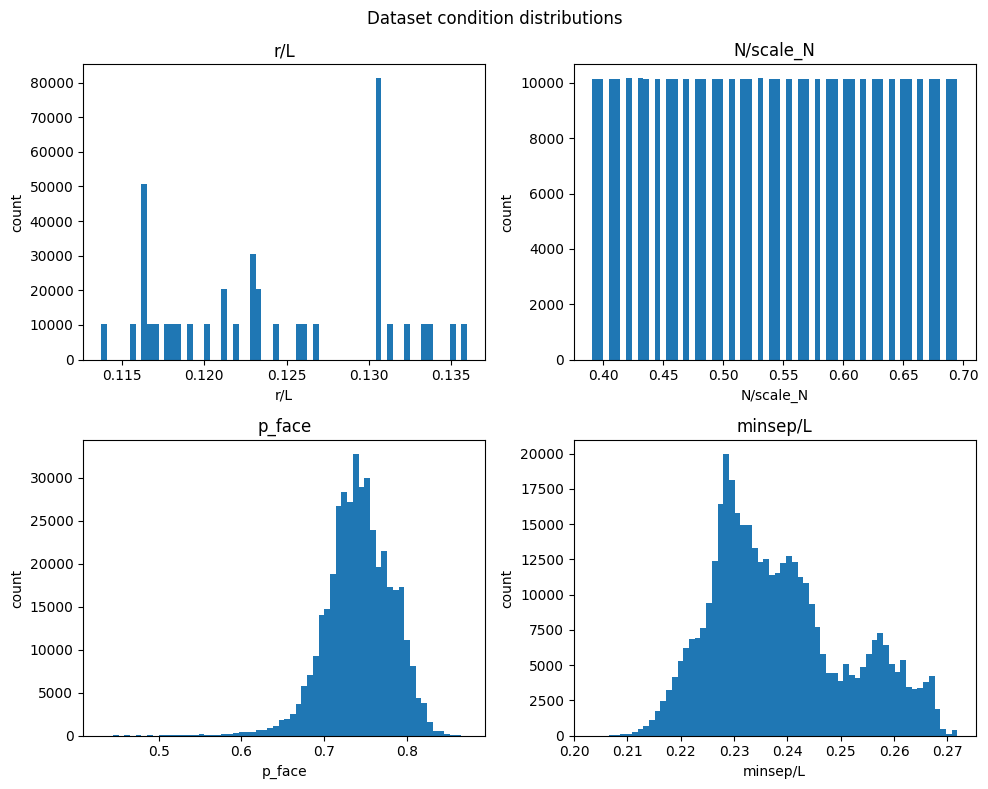

In [49]:
import torch
import matplotlib.pyplot as plt

for bi, (x, cond, mask) in enumerate(train_loader):
    # x: (B, d, Nmax)  cond: (B, 4)  mask: (B, Nmax) with True=attend
    print(f"batch {bi}: x{tuple(x.shape)} cond{tuple(cond.shape)} mask{tuple(mask.shape)} "
          f"| d={x.shape[1]}, Nmax={x.shape[2]}")
    if bi == 2:
        break

def collect_conditions(loader, max_batches=None):
    out = []
    for bi, (_, cond, _) in enumerate(loader):
        out.append(cond.cpu())
        if max_batches is not None and (bi + 1) >= max_batches:
            break
    return torch.cat(out, dim=0) if out else torch.empty(0, 4)

C = collect_conditions(train_loader, max_batches=None)  # shape: (num_samples, 4)
print("Collected cond shape:", tuple(C.shape))

names = ['r/L', 'N/scale_N', 'p_face', 'minsep/L']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i in range(4):
    # histogram per channel
    axes[i].hist(C[:, i].numpy(), bins=64)
    axes[i].set_title(names[i])
    axes[i].set_xlabel(names[i])
    axes[i].set_ylabel('count')
fig.suptitle('Dataset condition distributions', y=0.98)
plt.tight_layout()
plt.show()


In [50]:
for bi, (x, cond, mask) in enumerate(train_loader):
    N_eff = mask.sum(dim=1)           # (B,)
    print(f"batch {bi}: N_eff min={int(N_eff.min())}, max={int(N_eff.max())}, mean={float(N_eff.float().mean()):.2f}")
    if bi == 2:
        break


batch 0: N_eff min=50, max=89, mean=68.89
batch 1: N_eff min=50, max=89, mean=68.91
batch 2: N_eff min=50, max=89, mean=70.38


# Test

## Likelihood via ODESolver

In [100]:
dev = torch.device('cpu')

In [108]:
import torch
import torch.nn as nn
from torch.distributions import Normal, Independent
import matplotlib.pyplot as plt

def _extract_x_cond(batch, device):
    cond = None
    if isinstance(batch, (tuple, list)):
        x = batch[0]
        if len(batch) > 1:
            cond = batch[1]
    elif isinstance(batch, dict):
        x = batch.get('x', batch.get('data'))
        cond = batch.get('cond', None)
        if x is None:
            raise ValueError("Dict batch must contain key 'x' or 'data'.")
    else:
        x = batch

    x = x.to(device)
    if cond is not None:
        cond = cond.to(device)
    return x, cond


#Gaussian base log-density over FLAT state (B, D)
def make_gaussian_log_density(d: int, N: int, device, dtype):
    D = int(d) * int(N)
    base = Independent(Normal(torch.zeros(D, device=device, dtype=dtype),
                              torch.ones (D, device=device, dtype=dtype)), 1)
    def log_p0(x_flat: torch.Tensor) -> torch.Tensor:  # (B, D)
        return base.log_prob(x_flat)
    return log_p0


def build_solver(model, device, d= None, cond= None):
    # same as before; shown for completeness
    if d is None:
        if not hasattr(model, "d"):
            raise ValueError("Please pass `d` (per-point channel dim) or add `model.d`.")
        d = int(model.d)
    vel = TimeReversedVelocity(model, d=d, cond=cond).to(device)
    return ODESolver(velocity_model=vel)


@torch.no_grad()
def compute_model_loglikelihood(
    model: nn.Module,
    loader, 
    device,
    num_steps: int = 100, 
    num_acc: int = 10,
    exact_divergence: bool = False
):
    solver = build_solver(model, device)
    first_batch = next(iter(loader))
    xb, _ = _extract_x_cond(first_batch, device)
    _, d, N = xb.shape
    log_p0 = make_gaussian_log_density(d, N, device, xb.dtype)

    step_size = 1.0 / float(num_steps)
    all_logp = []

    for batch in loader:
        x, _ = _extract_x_cond(batch, device)
        x_flat = x.reshape(x.size(0), -1)

        if exact_divergence:
            _, log_p = solver.compute_likelihood(
                x_1=x_flat, method='midpoint', step_size=step_size,
                exact_divergence=True, log_p0=log_p0
            )
        else:
            # Hutchinson probe average
            log_p_acc = 0.0
            for _ in range(int(num_acc)):
                _, lp = solver.compute_likelihood(
                    x_1=x_flat, method='midpoint', step_size=step_size,
                    exact_divergence=False, log_p0=log_p0
                )
                log_p_acc = log_p_acc + lp
            log_p = log_p_acc / float(num_acc)

        all_logp.append(log_p.detach().cpu())

    return torch.cat(all_logp, dim=0)  # (total_samples,)


def visualize_model_loglikelihood(
    model: nn.Module,
    loader,
    device,
    num_steps: int = 100,
    num_acc: int = 10
):
    logp_hutch = compute_model_loglikelihood(
        model, loader, device,
        num_steps=num_steps, num_acc=num_acc, exact_divergence=False
    )
    logp_exact = compute_model_loglikelihood(
        model, loader, device,
        num_steps=num_steps, num_acc=1, exact_divergence=True
    )

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].hist(logp_hutch.numpy(), bins=50, alpha=0.85)
    axs[0].set_title(f"Model log-likelihood (Hutchinson, #acc={num_acc})")
    axs[0].set_xlabel("log p_model(x)")
    axs[0].set_ylabel("count")
    axs[0].grid(alpha=0.3)

    axs[1].hist(logp_exact.numpy(), bins=50, alpha=0.85)
    axs[1].set_title("Model log-likelihood (Exact divergence)")
    axs[1].set_xlabel("log p_model(x)")
    axs[1].set_ylabel("count")
    axs[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"[Hutchinson]  n={len(logp_hutch)}  mean={logp_hutch.mean():.6f}  std={logp_hutch.std():.6f}")
    print(f"[Exact]       n={len(logp_exact)}  mean={logp_exact.mean():.6f}  std={logp_exact.std():.6f}")

In [ ]:
# choose step size like the notebook
num_steps = 100          # so step_size = 1/100
num_acc   = 1           # Hutchinson averaging

visualize_model_loglikelihood(model, test_loader, dev, num_steps=num_steps, num_acc=num_acc)

# Model Loading for Inference

In [18]:
#ckpt_path = "diffuse_boost/output/saved_models/flow_model_loss=0.0756_20250817_064432.pth"
ckpt_path = "diffuse_boost/output/saved_models/flow_model_loss=0.0731_20250822_210828.pth"
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load(ckpt_path, map_location=device)
sd = ckpt.get("model_state_dict", ckpt.get("state_dict", ckpt))
if isinstance(sd, dict) and len(sd) and next(iter(sd)).startswith("module."):
    sd = {k[7:]: v for k,v in sd.items()}

p = ckpt.get("params", {})
# map aliases / fallbacks
if "num_isab" in p and "depth" not in p: p["depth"] = int(p["num_isab"])
d = int(p.get("dim_out", cfg["flow_matching"]["dimension"]))
st_kwargs = {
    "dim_hidden":   int(p.get("dim_hidden",   cfg["flow_matching"].get("st_dim_hidden", 512))),
    "num_heads":    int(p.get("num_heads",    cfg["flow_matching"].get("st_num_heads", 8))),
    "depth":        int(p.get("depth", 2)),
    "cond_dim_in":  int(p.get("cond_dim_in", 4)),
}
# optional keys if they were used during training
for k in ["ff_mult","attn_dropout","ff_dropout","dim_time","time_fourier_dim","time_hidden","time_fourier_sigma","cond_hidden"]:
    if k in p: st_kwargs[k] = type(p[k])(p[k])

model = FlowSetTransformer(d, **st_kwargs).to(device)
model.load_state_dict(sd, strict=True)
model.eval()

FlowSetTransformer(
  (time_emb): TimeEmbedFourier(
    (net): Sequential(
      (0): Linear(in_features=68, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
    )
  )
  (cond_mlp): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (token_in): Linear(in_features=131, out_features=512, bias=True)
  (timecond_to_film): Sequential(
    (0): SiLU()
    (1): Linear(in_features=128, out_features=1024, bias=True)
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0): ModuleList(
        (0): ModuleList(
          (0): RMSNorm()
          (1-2): 2 x None
        )
        (1): Attention(
          (to_q): Linear(in_features=512, out_features=512, bias=False)
          (to_k): Linear(in_features=512, out_features=512, bias=False)
          (to_v): Linear(in_features=512, out_features=512, bias=False)
          (split_q_heads)

# Metric Evaluation

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, betainc
from scipy.spatial import cKDTree
from collections import Counter, defaultdict

def shortest_vector_torus(p1, p2, box_size):
    delta = p1 - p2
    return delta - box_size * np.round(delta / box_size)

def _calculate_distances_and_overlaps(centers, radius, box_size, mode_flag):
    """
    Calculates max_overlap and all pairwise distances.
    """
    n, d = centers.shape
    target_dist = 2 * radius
    max_ov = 0.0
    all_distances = np.zeros(n * (n - 1) // 2, dtype=np.float64)
    dist_idx = 0
    for i in range(n):
        for j in range(i + 1, n):
            if mode_flag == 1:  # Torus
                vec = shortest_vector_torus(centers[i], centers[j], box_size)
            else:               # Box
                vec = centers[i] - centers[j]
            dist = np.sqrt(np.dot(vec, vec))
            all_distances[dist_idx] = dist
            dist_idx += 1
            if dist < target_dist:
                overlap = target_dist - dist
                if overlap > max_ov:
                    max_ov = overlap
    return max_ov, all_distances[:dist_idx]

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx != ry:
            self.parent[rx] = ry
            return True
        return False

def _dist_sq_box_or_torus(p, q, box_size, mode_flag):
    """
    mode_flag: 0=box (plain Euclidean), 1=torus (minimum image).
    """
    if mode_flag == 1:
        delta = p - q
        delta = delta - box_size * np.round(delta / box_size)
        return float(np.dot(delta, delta))
    else:
        d = p - q
        return float(np.dot(d, d))

def _compute_connectivity(centers, radius, box_size, mode_flag):
    centers = np.asarray(centers, dtype=np.float64)
    box_size = np.asarray(box_size, dtype=np.float64)
    n = centers.shape[0]
    if n == 0:
        return [], 0, np.array([])

    uf = UnionFind(n)
    min_distances = np.full(n, np.inf, dtype=np.float64)
    thr = 2.0 * float(radius)
    thr2 = thr * thr
    n_intersections_torus = 0

    for i in range(n):
        ci = centers[i]
        for j in range(i + 1, n):
            cj = centers[j]
            d2 = _dist_sq_box_or_torus(ci, cj, box_size, mode_flag)
            d  = np.sqrt(d2)
            if d < min_distances[i]: min_distances[i] = d
            if d < min_distances[j]: min_distances[j] = d
            if mode_flag == 1 and d2 < thr2:
                uf.union(i, j)
                n_intersections_torus += 1

    if mode_flag == 0:
        tree = cKDTree(centers)
        r_strict = np.nextafter(thr, -np.inf)
        pairs = tree.query_pairs(r=r_strict, output_type='ndarray')  # (M, 2)
        for i, j in pairs:
            uf.union(int(i), int(j))
        n_intersections = int(pairs.shape[0])
    else:
        n_intersections = n_intersections_torus

    groups_map = defaultdict(list)
    for i in range(n):
        groups_map[uf.find(i)].append(i)
    groups = list(groups_map.values())
    return groups, n_intersections, min_distances

def _intersection_volume_two_spheres(center1, center2, radius, d, box_size, mode_flag):
    """Intersection volume of two d-spheres via spherical caps."""
    if mode_flag == 1:
        vec = shortest_vector_torus(center1, center2, box_size)
    else:
        vec = center1 - center2
    dist = np.sqrt(np.dot(vec, vec))
    if dist >= 2 * radius:
        return 0.0
    sphere_volume_coeff = np.pi**(d/2) / gamma(d/2 + 1)
    sphere_volume = sphere_volume_coeff * radius**d
    if dist < 1e-9:
        return sphere_volume
    h = (2 * radius - dist) / 2
    x = (2 * radius * h - h**2) / radius**2
    cap_volume = 0.5 * sphere_volume * betainc((d + 1) / 2, 0.5, x)
    return 2 * cap_volume

def _monte_carlo_union_volume(cc_centers, radius, d, box_size, num_samples=10000):
    """Monte Carlo estimate of union volume for a component of spheres (box boundaries ignored for union)."""
    lower_corner = np.min(cc_centers, axis=0) - radius
    upper_corner = np.max(cc_centers, axis=0) + radius
    bounding_box_vol = np.prod(upper_corner - lower_corner)
    if bounding_box_vol < 1e-9:
        return 0.0
    samples = np.random.uniform(low=lower_corner, high=upper_corner, size=(num_samples, d))
    radius_sq = radius**2
    inside_any = np.zeros(num_samples, dtype=bool)
    for c in cc_centers:
        dist_sq = np.sum((samples - c)**2, axis=1)
        inside_any |= (dist_sq <= radius_sq)
    return bounding_box_vol * np.mean(inside_any)

def evaluate_packing(
    run,
    centers,
    radius,
    box_size,
    boundary_mode='box',
    plot_structural_metrics=True,
    compute_union_metrics=True,
    use_freud=False,
    mask=None
):
    """
    Evaluate one configuration.
      - centers: (N,d) numpy array (if padded, provide `mask` to select valid points)
      - radius : scalar sphere radius
      - box_size: scalar or (d,) side lengths
      - boundary_mode: 'box' or 'torus'
      - use_freud: ignored (kept for backward compatibility)
      - mask: optional boolean (N,)
    """
    centers = np.asarray(centers, dtype=np.float64)
    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        if mask.ndim != 1 or mask.shape[0] != centers.shape[0]:
            raise ValueError("mask must be shape (N,) matching centers")
        centers = centers[mask]
    n, d = centers.shape if centers.ndim == 2 else (0, 0)

    if n == 0:
        print(f"--- Evaluation for {run} skipped: No centers provided. ---")
        return {}

    box = np.array(box_size, float) if np.ndim(box_size) != 0 else np.full(d, float(box_size))
    if d != len(box):
        raise ValueError(f"Dimension mismatch: centers are {d}D but box_size has {len(box)} elements.")

    box_volume = np.prod(box)
    mode_flag = 1 if boundary_mode == 'torus' else 0

    max_ov, distances = _calculate_distances_and_overlaps(centers, radius, box, mode_flag)
    sphere_volume_coeff = np.pi**(d / 2) / gamma(d / 2 + 1)
    sphere_volume = sphere_volume_coeff * radius**d
    phi = (n * sphere_volume) / box_volume

    results = {
        "max_overlap": float(max_ov),
        "is_valid": bool(max_ov < 1e-8),
        "packing_fraction_phi": float(phi),
    }

    if compute_union_metrics:
        connected_components, n_intersections, min_dists = _compute_connectivity(centers, radius, box, mode_flag)

        union_volume = 0.0
        component_sizes = Counter()
        for cc_indices in connected_components:
            component_sizes[len(cc_indices)] += 1
            cc_centers = centers[cc_indices]
            if len(cc_indices) == 1:
                union_volume += sphere_volume
            elif len(cc_indices) == 2:
                vol_sum = 2 * sphere_volume
                vol_intersect = _intersection_volume_two_spheres(cc_centers[0], cc_centers[1], radius, d, box, mode_flag)
                union_volume += vol_sum - vol_intersect
            else:
                union_volume += _monte_carlo_union_volume(cc_centers, radius, d, box, num_samples=10000)

        total_individual_volume = n * sphere_volume
        total_intersection_volume = total_individual_volume - union_volume

        results.update({
            "union_volume_fraction": float(union_volume / box_volume),
            "num_intersections": int(n_intersections),
            "num_connected_components": int(len(connected_components)),
            "mean_nearest_neighbor_dist": float(np.mean(min_dists)),
            "min_nearest_neighbor_dist": float(np.min(min_dists)),
            "total_intersection_volume_ratio": float(
                total_intersection_volume / total_individual_volume if total_individual_volume > 0 else 0.0
            ),
            "component_size_distribution": dict(component_sizes)
        })

    # Optional 2D hexatic order (kept; not using freud)
    if d == 2:
        tree = cKDTree(centers)
        neighbor_list = tree.query_ball_tree(tree, r=1.2 * (2 * radius))
        psi6 = np.zeros(n, dtype=np.complex128)
        if boundary_mode == 'torus':
            box = np.array(box_size, float) if np.ndim(box_size) != 0 else np.full(d, float(box_size))
        for i in range(n):
            neighbors = [j for j in neighbor_list[i] if i != j]
            if len(neighbors) > 0:
                if boundary_mode == 'torus':
                    vecs = np.stack([shortest_vector_torus(centers[j], centers[i], box) for j in neighbors], axis=0)
                else:
                    vecs = centers[neighbors] - centers[i]
                angles = np.arctan2(vecs[:, 1], vecs[:, 0])
                psi6[i] = np.mean(np.exp(6j * angles))
        results["global_psi6_order"] = float(np.abs(np.mean(psi6)))


    return results


def evaluate_packing_batch(
    centers_batch,
    radii,
    box_size,
    boundary_mode='box',
    compute_union_metrics=True,
    masks=None,
    run_prefix="gen"
):
    """
    centers_batch: np.ndarray or torch.Tensor, shape (B, d, N)
    radii       : float or array-like (B,)
    masks       : None or bool array (B, N), True=attend
    Returns dict with per-sample lists and summary stats.
    """
    # to numpy
    if 'torch' in str(type(centers_batch)):
        centers_batch = centers_batch.detach().cpu().numpy()
    #if masks is not None and 'torch' in str(type(masks)):
    #    masks = masks.detach().cpu().numpy()
    if masks is not None:
        masks = np.asarray(masks)
        if masks.dtype != bool:
            masks = masks != 0
        if masks.shape != (B, N):
            # pad/truncate per sample to match N, minimal and safe
            fixed = np.zeros((B, N), dtype=bool)
            M = min(masks.shape[1], N)
            fixed[:, :M] = masks[:, :M]
            masks = fixed
            
    centers_batch = np.asarray(centers_batch)
    B, d, N = centers_batch.shape

    # radii handling
    if np.isscalar(radii):
        radii = np.full(B, float(radii), dtype=float)
    else:
        radii = np.asarray(radii, dtype=float).reshape(B,)

    per_sample = []
    for b in range(B):
        centers_bn = centers_batch[b].T  # (N,d)
        mask_b = masks[b] if masks is not None else None
        res = evaluate_packing(
            run=f"{run_prefix}_{b}",
            centers=centers_bn,
            radius=radii[b],
            box_size=box_size,
            boundary_mode=boundary_mode,
            compute_union_metrics=compute_union_metrics,
            use_freud=False,
            mask=mask_b
        )
        per_sample.append(res)

    def grab(key):
        return np.array([r.get(key, np.nan) for r in per_sample], dtype=float)

    agg = {
        "max_overlap_mean": np.nanmean(grab("max_overlap")),
        "max_overlap_std":  np.nanstd(grab("max_overlap")),
        "min_nnd_mean":     np.nanmean(grab("min_nearest_neighbor_dist")),
        "min_nnd_std":      np.nanstd(grab("min_nearest_neighbor_dist")),
        "phi_mean":         np.nanmean(grab("packing_fraction_phi")),
        "phi_std":          np.nanstd(grab("packing_fraction_phi")),
        "valid_frac":       float(np.mean([r.get("is_valid", False) for r in per_sample])),
        "num_connected_components_mean": np.nanmean(grab("num_connected_components")),
        "num_intersections_mean":        np.nanmean(grab("num_intersections")),
    }

    return {"per_sample": per_sample, "summary": agg}

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.spatial import cKDTree  # needed below

def _to_centers_np(x_event: torch.Tensor, mask: torch.Tensor = None) -> np.ndarray:
    """
    x_event: (d, N)
    mask   : (N,) bool, True=attend
    returns: (N_valid, d) np array
    """
    x = x_event.detach().cpu().float()
    if mask is not None:
        m = mask.detach().cpu().bool()
        x = x[:, m]
    return x.t().numpy()

def _collect_test_events(test_loader, max_events: int, L: float) -> tuple[list, list]:
    """
    Collect up to max_events events AND their per-sample radii from cond[:,0]*L.
    Returns: (events:list[(N_i,d)], radii:list[float])
    """
    events, radii = [], []
    for xb, cond, mask in test_loader:             # NEW: loader yields (x, cond, mask)
        B = xb.shape[0]
        r_batch = (cond[:, 0] * L).detach().cpu().numpy().tolist()  # per-sample radii
        for b in range(B):
            events.append(_to_centers_np(xb[b], mask[b]))
            radii.append(float(r_batch[b]))
            if len(events) >= max_events:
                return events, radii
    return events, radii

def _generated_events_from_model(model, optimizer, loader, num_events: int, batch_size: int, num_points: int,
                                 device, sphere_radius: float, clip_min: float, clip_max: float, dim: int) -> list:
    """
    Uses your sampler to get `num_events` generated events.
    Returns list of (N_valid, d) numpy arrays (padded points removed via mask).
    """
    out = sample_flow_model(
        model, optimizer, num_events, batch_size, num_points,
        device, sphere_radius, clip_min, clip_max, dim,
        cond_loader=loader, return_masks=True
    )

    # Unpack tuple from sampler
    if isinstance(out, tuple) and len(out) == 2:
        gen, gen_masks = out     # gen: (B,d,N), gen_masks: (B,N)
    else:
        # no masks returned (shouldn't happen here, but just in case)
        gen, gen_masks = out, None

    # Truncate to requested count
    num = min(num_events, gen.shape[0])
    gen = gen[:num]
    if gen_masks is not None:
        gen_masks = gen_masks[:num]

    # Convert each (d,N) → (N_valid,d) using mask when available
    events = []
    for i in range(num):
        xi = gen[i]                 # (d, N), numpy
        if gen_masks is not None:
            mi = gen_masks[i].astype(bool)   # (N,)
            xi = xi[:, mi]
        events.append(xi.T)          # (N_valid, d)
    return events


def evaluate_events(events: list, radii, box_len: float, boundary_mode='box') -> dict:
    """
    events: list of (N_i, d)
    radii : float or list/array (len == len(events))
    """
    agg = defaultdict(list)
    per_event_r = radii if isinstance(radii, (list, tuple, np.ndarray)) else [radii] * len(events)

    for idx, centers in enumerate(events):
        d = centers.shape[1]
        box_size = np.full(d, box_len, dtype=float)
        r_i = float(per_event_r[idx])

        res = evaluate_packing(
            run=f"event_{idx}",
            centers=centers,
            radius=r_i,
            box_size=box_size,
            boundary_mode=boundary_mode,
            plot_structural_metrics=False,
            compute_union_metrics=False,
            use_freud=False,      # freud disabled
            mask=None             # centers are already filtered
        )

        # nearest-neighbor distance (independent check)
        if len(centers) > 1:
            dists, _ = cKDTree(centers).query(centers, k=2)
            res["min_nearest_neighbor_dist"] = float(np.min(dists[:, 1]))
        else:
            res["min_nearest_neighbor_dist"] = float("inf")

        for k, v in res.items():
            if k in ("packing_fraction_phi", "is_valid"):
                continue
            if isinstance(v, (int, float, np.floating, np.integer, np.bool_)):
                agg[k].append(float(v))

    return agg

def _plot_hist_compare(ax, data_real, data_gen, title, xlabel, bins=50, density=False, log=True):
    ax.hist(data_real, bins=bins, alpha=0.6, label='Test', density=density, log=log)
    ax.hist(data_gen,  bins=bins, alpha=0.6, label='Generated', density=density, log=log)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('count' if not density else 'density')
    ax.grid(alpha=0.3)
    ax.legend()

def _print_metric_summary(name, real_vals, gen_vals):
    def stats(arr):
        arr = np.asarray(arr)
        return dict(n=len(arr), mean=float(arr.mean()), std=float(arr.std()),
                    min=float(arr.min()), max=float(arr.max()))
    r = stats(real_vals)
    g = stats(gen_vals)
    print(f"[{name}]")
    print(f"  Test     -> n={r['n']:<5d} mean={r['mean']:.6f}  std={r['std']:.6f}  min={r['min']:.6f}  max={r['max']:.6f}")
    print(f"  Generated-> n={g['n']:<5d} mean={g['mean']:.6f}  std={g['std']:.6f}  min={g['min']:.6f}  max={g['max']:.6f}")


def run_full_evaluation_and_plots(
    model,
    optimizer,
    test_loader,
    device,
    *,
    radius: float,          # kept for backward-compat; actual per-sample radii come from cond
    clip_range: float,
    d: int,
    num_points: int,
    num_eval_events: int = 256,
    gen_batch_size: int = 64,
    boundary_mode: str = 'box',
    use_freud: bool = False,   # ignored (no freud)
    density_hists: bool = False,
):
    model.eval()

    # Collect real/test events and per-sample radii (from cond[:,0] * L)
    L = float(clip_range)
    test_events, test_radii = _collect_test_events(test_loader, max_events=num_eval_events, L=L)
    if len(test_events) == 0:
        print("[error] No events collected from test loader.")
        return
    if len(test_events) < num_eval_events:
        print(f"[warn] Only {len(test_events)} events collected from test set (requested {num_eval_events}).")
        num_eval_events = len(test_events)
        test_radii = test_radii[:num_eval_events]

    # Use full box side length for evaluation; distances are Euclidean in 'box' mode.
    box_len = L

    # Generate events (sampler uses the same test_loader order for conditioning)
    gen_events = _generated_events_from_model(
        model, optimizer, test_loader, num_eval_events, gen_batch_size, num_points,
        device, radius, clip_range, clip_range, d
    )
    # Reuse the per-sample radii from the same conditioning sequence
    gen_radii = test_radii[:len(gen_events)]

    # Evaluate
    eval_real = evaluate_events(test_events, radii=test_radii, box_len=box_len, boundary_mode=boundary_mode)
    eval_gen  = evaluate_events(gen_events,  radii=gen_radii,  box_len=box_len, boundary_mode=boundary_mode)

    comparable = sorted(set(eval_real.keys()).intersection(set(eval_gen.keys())))
    for drop_key in ("packing_fraction_phi", "is_valid"):
        if drop_key in comparable:
            comparable.remove(drop_key)

    print("\n=== Evaluation Summary (per-event metrics) ===")
    for k in comparable:
        _print_metric_summary(k, eval_real[k], eval_gen[k])

    nplots = len(comparable)
    cols = 2
    rows = (nplots + cols - 1) // cols if nplots > 0 else 1
    fig, axs = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    axs = np.array(axs).reshape(rows, cols)

    i = 0
    for k in comparable:
        r = eval_real[k]
        g = eval_gen[k]
        ax = axs[i // cols, i % cols]
        _plot_hist_compare(ax, r, g, title=k, xlabel=k, bins=50, density=density_hists, log=True)
        i += 1

    # clean empty subplots
    while i < rows * cols:
        fig.delaxes(axs[i // cols, i % cols])
        i += 1

    plt.tight_layout()
    plt.show()
    return dict(real=eval_real, gen=eval_gen, comparable_keys=comparable, box_len=box_len)


### Sampling with ODESolver with PCFM --> (Best Version!)

In [18]:
@torch.no_grad()
def sample_flow_model(model, optimizer, num_samples, batch_size, num_points,
                      device, sphere_radius, clip_min, clip_max, dim, 
                      cond_loader=None, return_masks = False):

    # Hyperparameters
    N_steps = 100
    ode_method = 'midpoint'
    ode_step_cap = 0.1
    jitter = 5e-3
    eps_nrm = 1e-6
    proj_outer_iters = 8
    alpha_proj = 0.25
    contact_q = 1.0
    wall_weight = 1.0
    wall_margin = 0.05
    prox_iters = 10
    prox_step = 0.2
    prox_lambda = 2.0
    final_passes = 20
    tol_finish = 1e-8

    L = torch.tensor(float(clip_max), device=device)
    r_default = torch.tensor(float(sphere_radius), device=device)

    def _clamp_box_local(x, r_b):
        return _box_clamp(x, r_b, L)

    class _FMVF:
        def __init__(self, mdl, cond, mask):
            self.mdl, self.cond, self.mask = mdl, cond, mask
        def __call__(self, x, t, **_):
            tb = torch.full((x.size(0),), float(t), device=x.device, dtype=x.dtype)
            return self.mdl(tb, x, cond=self.cond, mask=self.mask) if self.cond is not None else self.mdl(tb, x, mask=self.mask)

    def _ode_solve_with_model(x_init, tau_start, tau_end, cond, mask, r_b):
        t0, t1 = 1.0 - float(tau_start), 1.0 - float(tau_end)
        solver = ODESolver(velocity_model=_FMVF(model, cond, mask))
        T = torch.tensor([t0, t1], device=x_init.device, dtype=x_init.dtype)
        dt = abs(t1 - t0)
        step_size = min(ode_step_cap, max(1e-3, dt))
        x_end = solver.sample(time_grid=T, x_init=x_init, method=ode_method,
                              step_size=step_size, return_intermediates=False, enable_grad=False)
        return _clamp_box_local(x_end, r_b)

    def _active_overlap(u, r_b, mask, for_stop=False):
        """
        Returns overlap>=0 on active pairs only; masked pairs set to 0.
        """
        B, d, N = u.shape
        P = u.permute(0, 2, 1).contiguous()         # (B,N,d)
        if not for_stop and eps_nrm > 0.0:
            P = P + (eps_nrm * r_b.view(-1, 1, 1)) * torch.randn_like(P)

        diff = P[:, :, None, :] - P[:, None, :, :]  # (B,N,N,d)
        dist = diff.norm(dim=-1).clamp_min(1e-12)   # (B,N,N)
        n    = diff / dist.unsqueeze(-1)            # (B,N,N,d)

        overlap = (2.0 * r_b.view(-1,1,1) - dist)   # (B,N,N)
        eye = torch.eye(N, device=u.device, dtype=torch.bool)[None]
        pairmask = (mask[:, :, None] & mask[:, None, :]) & (~eye)
        overlap = torch.where(pairmask, overlap, torch.zeros_like(overlap))
        return overlap, n, eye

    def _select_active(overlap, eye, q=1.0):
        pos = (overlap > 0) & (~eye)
        if q >= 1.0:
            return pos
        flat = overlap.clone()
        flat[~pos] = float('-inf')
        thr = torch.quantile(flat.view(flat.size(0), -1), 1.0 - q, dim=1, keepdim=True)
        return pos & (overlap >= thr.view(-1, 1, 1))

    def _JJt_inv_h_times_Jt(overlap, n, eye, q):
        active = _select_active(overlap, eye, q)
        w = (0.5 * overlap * active.float())                    # (B,N,N)
        term_i = (w.unsqueeze(-1) * n).sum(dim=2)               # (B,N,d)
        term_j = (w.transpose(1, 2).unsqueeze(-1)
                  * n.transpose(1, 2)).sum(dim=2)               # (B,N,d)
        delta = term_i - term_j                                 # (B,N,d)
        deg = active.float().sum(dim=2, keepdim=True).clamp_min(1.0)
        delta = (delta / deg).permute(0, 2, 1)                  # (B,d,N)
        return delta

    def _wall_push(u, r_b, mask, margin_frac=0.05, scale=1.0):
        B, d, N = u.shape
        delta = torch.zeros_like(u)
        thr = margin_frac * (2.0 * r_b).view(-1, 1, 1)
        for ax in range(d):
            dl = u[:, ax, :] - r_b.view(-1, 1)                  # dist to low face
            dh = (L - r_b).view(-1, 1) - u[:, ax, :]            # dist to high face
            near_low  = (dl < thr.view(-1,1))
            near_high = (dh < thr.view(-1,1))
            delta[:, ax, :] += torch.where(near_low,  (thr.view(-1,1) - dl), 0.0)
            delta[:, ax, :] -= torch.where(near_high, (thr.view(-1,1) - dh), 0.0)
        # zero out on padded tokens
        delta = delta * mask[:, None, :].to(delta.dtype)
        return scale * delta

    def _project_terminal(u, r_b, mask):
        for _ in range(proj_outer_iters):
            overlap, n, eye = _active_overlap(u, r_b, mask, for_stop=False)
            has_pairs = bool((overlap > 0).any())
            if not has_pairs and wall_weight <= 0.0:
                break
            delta_pairs = _JJt_inv_h_times_Jt(overlap, n, eye, contact_q) if has_pairs else 0.0
            delta_walls = _wall_push(u, r_b, mask, margin_frac=wall_margin, scale=wall_weight) if wall_weight > 0.0 else 0.0
            u = _clamp_box_local(u + alpha_proj * (delta_pairs + delta_walls), r_b)
        return u

    def _Jt_h_at_state(u_next, r_b, mask):
        overlap, n, eye = _active_overlap(u_next, r_b, mask, for_stop=False)
        active = (overlap > 0) & (~eye)
        w = overlap * active.float()
        term_i = (-(w.unsqueeze(-1) * n).sum(dim=2))                       # (B,N,d)
        term_j = (+(w.transpose(1, 2).unsqueeze(-1) * n.transpose(1, 2)).sum(dim=2))
        jt_pairs = (term_i + term_j).permute(0, 2, 1)                      # (B,d,N)
        jt_walls = _wall_push(u_next, r_b, mask, margin_frac=wall_margin, scale=1.0)
        return jt_pairs + wall_weight * jt_walls

    def _prox_relaxed(u, u0, u_proj, tau_prime, cond, r_b, mask):
        u_hat = (1.0 - tau_prime) * u0 + tau_prime * u_proj
        t_prime = 1.0 - float(tau_prime)
        for _ in range(max(1, prox_iters)):
            tb = torch.full((u.size(0),), t_prime, device=u.device, dtype=u.dtype)
            v = model(tb, u, cond=cond, mask=mask) if cond is not None else model(tb, u, mask=mask)
            u_next = _clamp_box_local(u + (1.0 - tau_prime) * v, r_b)
            jt_h = _Jt_h_at_state(u_next, r_b, mask)
            grad = (u - u_hat) + prox_lambda * jt_h
            u = _clamp_box_local(u - prox_step * grad, r_b)
        return u

    def _final_polish(u, r_b, mask):
        for _ in range(final_passes):
            overlap, _, _ = _active_overlap(u, r_b, mask, for_stop=True)
            if float(overlap.clamp_min(0.0).amax()) <= tol_finish:
                break
            u = _project_terminal(u, r_b, mask)
        return u

    model.eval()
    optimizer.eval()

    samples, masks_out, remaining = [], [], int(num_samples)
    cond_iter = iter(cond_loader) if cond_loader is not None else None

    while remaining > 0:
        bs = min(batch_size, remaining)
        if cond_iter is not None:
            try:
                x_dummy, cond, mask = next(cond_iter)
            except StopIteration:
                cond_iter = iter(cond_loader)
                x_dummy, cond, mask = next(cond_iter)
            cond = cond.to(device)
            mask = mask.to(device)                  # (B, Ncond_max)
            if cond.size(0) > bs:
                cond = cond[:bs]
                mask = mask[:bs]
            #extrapolative de novo design
            cond = cond.clone()
            cond[:, 3] = cond[:, 3] + 0.05

            # per-sample radius
            r_batch = (cond[:, 0] * L).to(torch.float32)        # (B,)

            # we keep fixed output width N=num_points; adapt mask to that width
            if mask.size(1) < num_points:
                pad = torch.zeros(mask.size(0), num_points - mask.size(1), dtype=mask.dtype, device=device)
                mask = torch.cat([mask, pad], dim=1)
            elif mask.size(1) > num_points:
                mask = mask[:, :num_points]
        else:
            cond = None
            r_batch = r_default.repeat(bs)                      # (B,)
            mask = torch.ones(bs, num_points, dtype=torch.bool, device=device)

        # Initialize u0 at tau=0, clamp
        p_face_batch = cond[:, 2].clamp(0, 1) if cond is not None else None
        u0 = _sample_x1_box_faces_per_batch(
            torch.empty(bs, dim, num_points, device=device),
            r_batch, L=L, p_face_batch=p_face_batch, jitter=jitter
        )
        u0 = _clamp_box_local(u0, r_batch)
        u = u0.clone()

        # tau grid evolution
        for k in range(N_steps):
            tau      = k / N_steps
            tau_next = (k + 1) / N_steps
            # forward shoot to tau=1
            u1 = _ode_solve_with_model(u, tau, 1.0, cond, mask, r_batch)
            # terminal projection
            u_proj = _project_terminal(u1, r_batch, mask)
            # relaxed reverse step
            u = _prox_relaxed(u, u0, u_proj, tau_next, cond, r_batch, mask)

        u = _final_polish(u, r_batch, mask)
        samples.append(u.cpu().numpy())
        if return_masks:
            masks_out.append(mask.cpu().numpy())
        remaining -= bs

    samples_np = np.concatenate(samples, axis=0)          # (num_samples, d, num_points)
    if return_masks:
        masks_np = np.concatenate(masks_out, axis=0)      # (num_samples, num_points)
        return samples_np, masks_np
    return samples_np


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=1000  mean=0.009792  std=0.005827  min=0.000000  max=0.035411
  Generated-> n=1000  mean=0.029905  std=0.005574  min=0.015207  max=0.053490
[min_nearest_neighbor_dist]
  Test     -> n=1000  mean=0.238626  std=0.012594  min=0.208778  max=0.269870
  Generated-> n=1000  mean=0.218514  std=0.014074  min=0.185112  max=0.249406


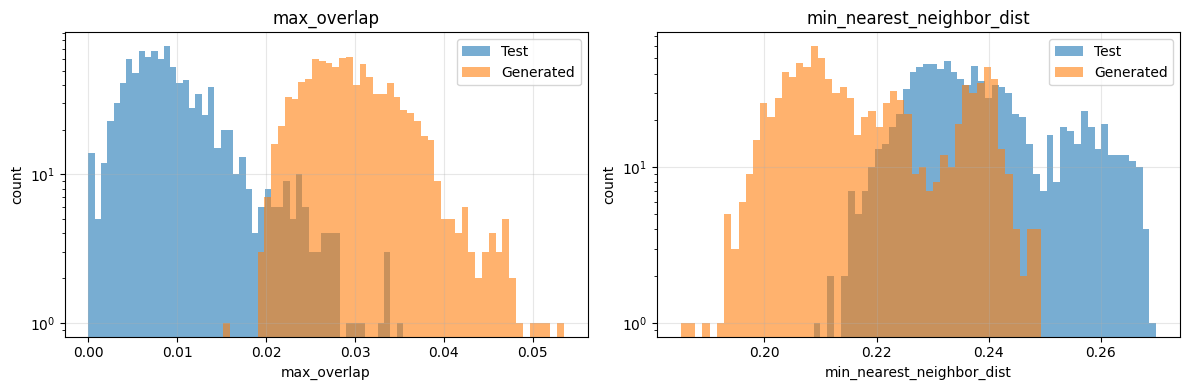

In [19]:
gen_points = pts
base_ds = getattr(test_loader.dataset, 'dataset', None)
if base_ds is not None and getattr(base_ds, 'mixed_mode', False):
    gen_points = max(g["N"] for g in base_ds.groups)

results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,   #(x, cond, mask), per-sample r used internally
    device=dev,
    radius=radius,             # kept for signature; sampler uses cond radii since cond_loader is set
    clip_range=clip_r,
    d=d,
    num_points=gen_points,
    num_eval_events=1000,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=1000  mean=0.003656  std=0.001904  min=0.000066  max=0.009990
  Generated-> n=1000  mean=0.024519  std=0.005743  min=0.014163  max=0.048400
[min_nearest_neighbor_dist]
  Test     -> n=1000  mean=0.223884  std=0.001904  min=0.217549  max=0.227474
  Generated-> n=1000  mean=0.203020  std=0.005743  min=0.179139  max=0.213377


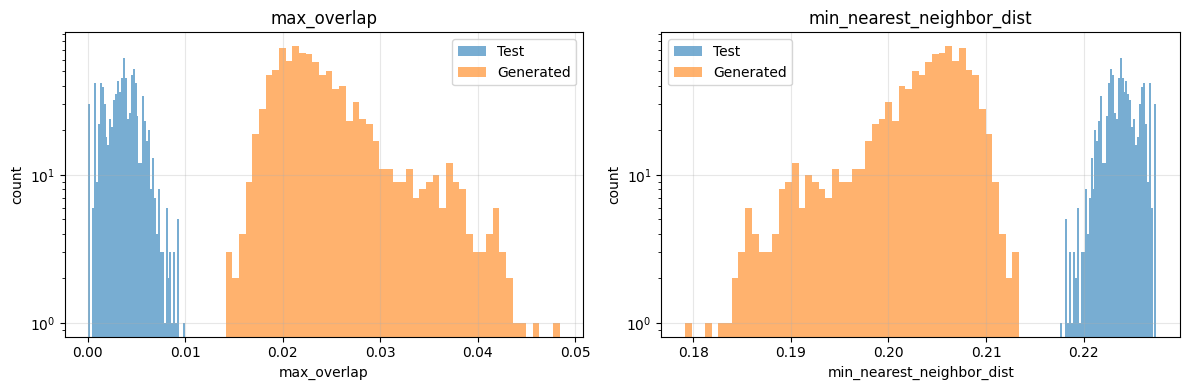

In [40]:
#Sampling with PCFM v2 (BEST)
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=1000,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)


=== Evaluation Summary (per-event metrics) ===
[max_overlap]
  Test     -> n=1000  mean=0.003656  std=0.001904  min=0.000066  max=0.009990
  Generated-> n=1000  mean=0.023812  std=0.004809  min=0.015070  max=0.046354
[min_nearest_neighbor_dist]
  Test     -> n=1000  mean=0.223884  std=0.001904  min=0.217549  max=0.227474
  Generated-> n=1000  mean=0.203728  std=0.004809  min=0.181185  max=0.212469


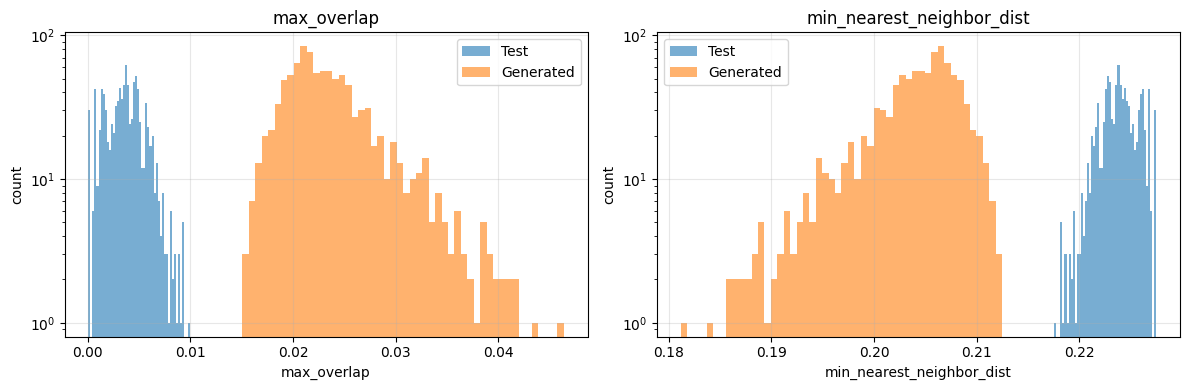

In [68]:
#Sampling with PCFM v2 (BEST)
results = run_full_evaluation_and_plots(
    model=model,
    optimizer=opt,
    test_loader=test_loader,
    device=dev,
    radius=radius,
    clip_range=clip_r,
    d=d,
    num_points=pts,
    num_eval_events=1000,
    gen_batch_size=100,
    boundary_mode='box',
    use_freud=False,
    density_hists=False
)